# KASBench Analysis
## Download and Preprocessing

This notebook downloads the KASBench dataset from S3 and performs some basic preprocessing steps.



In [1]:
%load_ext autoreload
%autoreload 2

In [378]:
import io
import json
import os
import datetime   
import importlib
from __future__ import annotations
from dataclasses import dataclass


import boto3
import pandas as pd
import numpy as np
import sqlite3
import pyperclip
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from prometheus_api_client import PrometheusConnect, MetricRangeDataFrame


import common

from common import (
    get_s3_file_listing, 
    is_locust_db, 
    download_locust_db, 
    parse_locust_db_file_info,
    create_log_database,
    get_raw_log_as_dataframe,
    get_log_as_dataframe,
    get_run_details,
    get_autoscaler,
    get_trial_summary_df,
    get_autoscaler_summary,
    parse_roundtrip_file_info,
    merge_roundtrip_completion_percentage,
    calculate_theta_metrics,
    calculate_tau_metrics,
    append_time_slice,
    add_weighted_theta,
    add_weighted_tau,
    calculate_async_utilization_by_autoscaler,
    parse_run_details_file_info,
    get_run_start_and_end_times,
    get_asynchronous_metrics,
    )

importlib.reload(common)


<module 'common' from '/Users/noahkrieger/projects/dissertation/kasbench/kasbench-analysis/src/common.py'>

### Get environmental variables

In [237]:
load_dotenv()
s3_bucket = os.environ.get("S3_BUCKET")
print(f"S3 Bucket: {s3_bucket}")

S3 Bucket: kasbench-test-20260528-377288663341-us-east-1-an


### Set constants and create directories

In [238]:
RUN = "exp-2026-08-02-c"
DATA_DIR = f"../data/{RUN}"
os.makedirs(DATA_DIR, exist_ok=True)
RUN_DB = f"{DATA_DIR}/logs.db"
print(f"Run database is {RUN_DB}")


Run database is ../data/exp-2026-08-02-c/logs.db


### Get the file listing from S3   

In [239]:
files = get_s3_file_listing(s3_bucket, s3_prefix=RUN)


### Iterate the file listing and download all the Locust databases to local storage

In [240]:
# Delete the log database if it already exists
if os.path.exists(RUN_DB):
    os.remove(RUN_DB)

# Create the log database
create_log_database(RUN_DB)

# Populate the log database from the locust database files
for file_info in files:
    # skip non-database files
    if not is_locust_db(file_info):
        continue
    
    # parse trial, role, and filename from the S3 file info
    trial, role, filename = parse_locust_db_file_info(file_info)

    # get the autoscaler from the run details
    run_details = get_run_details(s3_bucket, RUN, trial)
    autoscaler = get_autoscaler(run_details)

    # skip if it-operations.  It operations transactions are not tracked for response time/failure rate
    if role == "it-operations":
        continue
    
    # download the database if it doesn't already exist
    local_path = download_locust_db(DATA_DIR, s3_bucket, file_info["Key"], trial, role, filename)
    
    # load as a dataframe, augmented with run id, trial id, and role
    df = get_raw_log_as_dataframe(local_path)
    df["run_id" ] = RUN
    df["trial_id" ] = trial
    df["role" ] = role
    df["autoscaler" ] = autoscaler
    df["success"] = (
        pd.to_numeric(df["status_code"], errors="coerce")
          .between(200, 299)
        )
    df["failure"] = ~df["success"]

    # append to the sqlite database
    df.to_sql('logs', sqlite3.connect(RUN_DB), if_exists='append', index=False)
    


    


### Load the aggregate database into a dataframe for analysis

In [241]:
df = get_log_as_dataframe(RUN_DB)
raw_df = df.copy()
df

,run_id,trial_id,role,autoscaler,user_id,request_type,name,response_time,response_length,response,status_code,reason,exception,start_time,url,method_and_name,success,failure
0,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,POST,/api/portfolios/bulk,37.952766,140,<Response [201]>,201,Created,None,2026-08-02 16:10:50.149567,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
1,exp-2026-08-02-c,trial0001,back-office,vpa,57a15a67-4cf1-40ab-93a4-501a120369da,GET,/api/portfolios/{id},29.993266,133,<Response [200]>,200,OK,None,2026-08-02 16:10:55.388726,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
2,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,GET,/api/portfolios/{id},19.078246,133,<Response [200]>,200,OK,None,2026-08-02 16:10:56.047427,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
3,exp-2026-08-02-c,trial0001,back-office,vpa,6f30fe02-1471-407b-8d1b-c595820215fd,POST,/api/portfolios/bulk,25.788154,140,<Response [201]>,201,Created,None,2026-08-02 16:10:56.638008,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
4,exp-2026-08-02-c,trial0001,back-office,vpa,48c703ae-ad00-4893-9724-d40ba747dda9,GET,/api/portfolios/{id},22.076400,133,<Response [200]>,200,OK,None,2026-08-02 16:10:58.535957,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234114,exp-2026-08-02-c,trial0012,trader,hpa,2569a186-c143-47ff-b52c-90aefa84a63b,POST,/api/trade-orders/batch/submit,29.189712,1044,<Response [200]>,200,OK,None,2026-08-03 00:49:57.041504,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234115,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,13.796214,622,<Response [200]>,200,OK,None,2026-08-03 00:50:04.550745,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0
234116,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,POST,/api/trade-orders/batch/submit,34.278593,1045,<Response [200]>,200,OK,None,2026-08-03 00:50:04.570462,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234117,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,24.098116,624,<Response [200]>,200,OK,None,2026-08-03 00:50:05.332916,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0


### Summarize the trials

In [242]:
trial_summary_df = get_trial_summary_df(df)
trial_summary_df

,autoscaler,trial_id,requests,mean_response_time,failures,failure_rate
0,hpa,trial0008,19261,2067.239654,412,0.021390
1,hpa,trial0012,21680,245.180317,15,0.000692
2,keda,trial0003,22299,203.104362,32,0.001435
3,keda,trial0005,22125,198.235355,33,0.001492
4,keda,trial0007,22585,718.315986,442,0.019571
5,none,trial0004,21447,359.395990,30,0.001399
6,none,trial0006,15843,4333.210904,2220,0.140125
7,none,trial0009,18127,3309.908008,882,0.048657
8,none,trial0011,16445,4172.390502,3425,0.208270
9,vpa,trial0001,20160,943.266149,1050,0.052083


### Merge Roundtrip Percentage

In [243]:
merged_trial_summary_df = merge_roundtrip_completion_percentage(files, s3_bucket, trial_summary_df)
merged_trial_summary_df


,autoscaler,trial_id,requests,mean_response_time,failures,failure_rate,quantity_ordered,quantity_placed,quantity_filled,roundtrip_completion_percentage
0,hpa,trial0008,19261,2067.239654,412,0.021390,7743696,7743696,719444,9.290706
1,hpa,trial0012,21680,245.180317,15,0.000692,7202477,7202477,644967,8.954794
2,keda,trial0003,22299,203.104362,32,0.001435,6957005,6957005,1141738,16.411344
3,keda,trial0005,22125,198.235355,33,0.001492,9403975,9403975,1460188,15.527349
4,keda,trial0007,22585,718.315986,442,0.019571,8530134,8530134,1376311,16.134694
5,none,trial0004,21447,359.395990,30,0.001399,6081593,6081593,605877,9.962472
6,none,trial0006,15843,4333.210904,2220,0.140125,3996477,3996477,558393,13.972131
7,none,trial0009,18127,3309.908008,882,0.048657,5221906,5221906,646808,12.386435
8,none,trial0011,16445,4172.390502,3425,0.208270,3691791,3691791,743930,20.150924
9,vpa,trial0001,20160,943.266149,1050,0.052083,8299650,8299650,860898,10.372702


In [244]:
merged_trial_summary_df.columns

Index(['autoscaler', 'trial_id', 'requests', 'mean_response_time', 'failures',
       'failure_rate', 'quantity_ordered', 'quantity_placed',
       'quantity_filled', 'roundtrip_completion_percentage'],
      dtype='str')

### Aggregate the summarized trials

In [245]:
autoscaler_summary = get_autoscaler_summary(merged_trial_summary_df)
autoscaler_summary

,autoscaler,trials,mean_rt,median_rt,sd_rt,mean_failure_rate,median_failure_rate,sd_failure_rate,mean_roundtrip_completion_percentage,median_roundtrip_completion_percentage,sd_roundtrip_completion_percentage,total_quantity_ordered,total_quantity_placed,total_quantity_filled,ci95_rt,ci95_failure_rate,ci95_roundtrip_completion_percentage,pooled_roundtrip_completion_percentage
0,hpa,2,1156.209985,1156.209985,1288.390513,0.011041,0.011041,0.014636,9.122750,9.122750,0.237525,14946173,14946173,1364411,11575.729488,0.131500,2.134079,9.128832
1,keda,3,373.218568,203.104362,298.873046,0.007499,0.001492,0.010454,16.024462,16.134694,0.452189,24891114,24891114,3978237,742.441805,0.025970,1.123300,15.982559
2,none,4,3043.726351,3741.149255,1845.095783,0.099613,0.094391,0.092539,14.117991,13.179283,4.346806,18991767,18991767,2555008,2935.959128,0.147249,6.916739,13.453240
3,vpa,3,3428.250715,2365.336928,3153.768914,0.134267,0.083741,0.116015,15.255629,12.470408,6.723129,19555001,19555001,2622404,7834.396293,0.288198,16.701179,13.410401


### Visualize the results

#### Plot mean response time by autoscaler


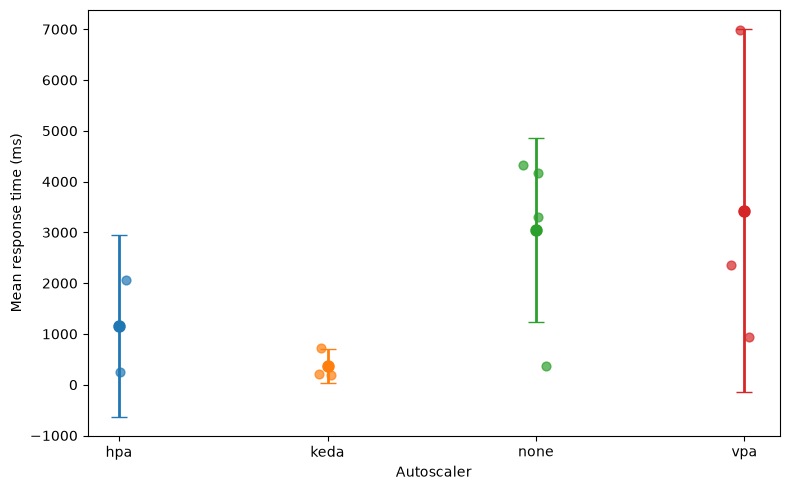

In [246]:
fig, ax = plt.subplots(figsize=(8,5))

autoscalers = sorted(merged_trial_summary_df["autoscaler"].unique())

for i, a in enumerate(autoscalers):
    d = trial_summary_df[trial_summary_df.autoscaler == a]

    # jittered trial means
    x = np.random.normal(i, 0.04, len(d))
    ax.scatter(x, d["mean_response_time"],
               alpha=0.7, s=40)

    mean = d["mean_response_time"].mean()
    se = d["mean_response_time"].std(ddof=1) / np.sqrt(len(d))

    ax.errorbar(
        i,
        mean,
        yerr=1.96 * se,
        fmt="o",
        capsize=6,
        markersize=8,
        linewidth=2,
    )

ax.set_xticks(range(len(autoscalers)))
ax.set_xticklabels(autoscalers)
ax.set_ylabel("Mean response time (ms)")
ax.set_xlabel("Autoscaler")

plt.tight_layout()

In [247]:
fig.savefig(
    "../figures/response_time_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot failure rate by autoscaler


In [248]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_failure_rate_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level failure rates by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial failure rates. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - failure_rate

        failure_rate must be expressed as a proportion, e.g. 0.025 for 2.5%.

    autoscaler_order:
        Optional display order. Autoscalers not listed here are appended
        alphabetically.

    confidence_level:
        Confidence level for the error bars. Default is 0.95.

    random_seed:
        Seed used to make horizontal point jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {"autoscaler", "trial_id", "failure_rate"}
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            f"trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        ["autoscaler", "trial_id", "failure_rate"]
    ].copy()

    plot_df["failure_rate"] = pd.to_numeric(
        plot_df["failure_rate"],
        errors="coerce",
    )

    if plot_df["failure_rate"].isna().any():
        bad_rows = plot_df.loc[plot_df["failure_rate"].isna()]
        raise ValueError(
            "failure_rate contains missing or nonnumeric values. "
            f"Invalid rows:\n{bad_rows}"
        )

    if not plot_df["failure_rate"].between(0, 1).all():
        bad_rows = plot_df.loc[
            ~plot_df["failure_rate"].between(0, 1)
        ]
        raise ValueError(
            "failure_rate must be between 0 and 1. "
            f"Invalid rows:\n{bad_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].dropna().unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    rng = np.random.default_rng(random_seed)

    fig, ax = plt.subplots(figsize=(8, 5.5))

    alpha = 1 - confidence_level
    summary_rows = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ]

        rates_percent = (
            autoscaler_df["failure_rate"].to_numpy() * 100
        )

        # Add slight horizontal jitter so overlapping trial points remain visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=len(rates_percent),
        )

        ax.scatter(
            jittered_x,
            rates_percent,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        number_of_trials = len(rates_percent)
        mean_rate = rates_percent.mean()

        if number_of_trials >= 2:
            standard_deviation = rates_percent.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            confidence_interval_half_width = np.nan

        ax.errorbar(
            position,
            mean_rate,
            yerr=confidence_interval_half_width,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_failure_rate": mean_rate / 100,
                "sd_failure_rate": standard_deviation / 100,
                "se_failure_rate": standard_error / 100,
                "ci_lower": (
                    max(
                        0,
                        mean_rate
                        - confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
                "ci_upper": (
                    min(
                        100,
                        mean_rate
                        + confidence_interval_half_width,
                    )
                    / 100
                    if number_of_trials >= 2
                    else np.nan
                ),
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Failure rate (%)")
    ax.set_title(
        "Failure Rate by Autoscaler\n"
        "Trial-level rates with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    ax.set_ylim(bottom=0)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

    fig.tight_layout()

    # The summary can be retrieved from the axes for later use if desired.
    ax.failure_rate_summary = pd.DataFrame(summary_rows)

    return fig, ax

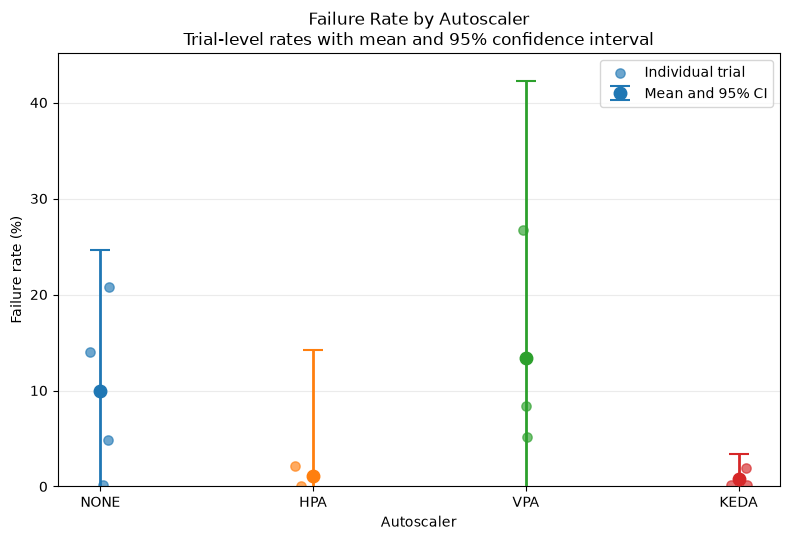

In [249]:
fig, ax = plot_failure_rate_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [250]:
fig.savefig(
    "../figures/failure_rate_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

#### Plot of roundtrip completion percentage by autoscaler

In [251]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import t


def plot_roundtrip_completion_by_autoscaler(
    trial_summary: pd.DataFrame,
    *,
    autoscaler_order: list[str] | None = None,
    confidence_level: float = 0.95,
    random_seed: int = 42,
) -> tuple[plt.Figure, plt.Axes]:
    """
    Plot trial-level round-trip completion percentages by autoscaler.

    Each small point represents one trial. The larger point represents the
    unweighted mean of the trial percentages. Error bars show a two-sided
    Student-t confidence interval for the mean.

    Parameters
    ----------
    trial_summary:
        DataFrame containing:
          - autoscaler
          - trial_id
          - roundtrip_completion_percentage

        roundtrip_completion_percentage must be expressed in percentage
        points, such as 9.3 for 9.3%, rather than 0.093.

    autoscaler_order:
        Optional display order. Autoscalers present in the dataframe but not
        listed here are appended alphabetically.

    confidence_level:
        Confidence level for the error bars. Defaults to 0.95.

    random_seed:
        Seed used to make the horizontal jitter reproducible.

    Returns
    -------
    tuple[matplotlib.figure.Figure, matplotlib.axes.Axes]
        The generated figure and axes.
    """
    required_columns = {
        "autoscaler",
        "trial_id",
        "roundtrip_completion_percentage",
    }
    missing_columns = required_columns - set(trial_summary.columns)

    if missing_columns:
        raise ValueError(
            "trial_summary is missing required columns: "
            f"{sorted(missing_columns)}"
        )

    if not 0 < confidence_level < 1:
        raise ValueError("confidence_level must be between 0 and 1.")

    plot_df = trial_summary[
        [
            "autoscaler",
            "trial_id",
            "roundtrip_completion_percentage",
        ]
    ].copy()

    if plot_df["autoscaler"].isna().any():
        raise ValueError("autoscaler contains missing values.")

    if plot_df["trial_id"].isna().any():
        raise ValueError("trial_id contains missing values.")

    plot_df["roundtrip_completion_percentage"] = pd.to_numeric(
        plot_df["roundtrip_completion_percentage"],
        errors="coerce",
    )

    if plot_df["roundtrip_completion_percentage"].isna().any():
        bad_rows = plot_df.loc[
            plot_df["roundtrip_completion_percentage"].isna()
        ]
        raise ValueError(
            "roundtrip_completion_percentage contains missing or "
            f"nonnumeric values:\n{bad_rows}"
        )

    if not plot_df["roundtrip_completion_percentage"].between(
        0, 100
    ).all():
        bad_rows = plot_df.loc[
            ~plot_df["roundtrip_completion_percentage"].between(0, 100)
        ]
        raise ValueError(
            "roundtrip_completion_percentage must be between 0 and 100. "
            f"Invalid rows:\n{bad_rows}"
        )

    # Prevent a trial from being counted more than once for an autoscaler.
    duplicate_mask = plot_df.duplicated(
        subset=["autoscaler", "trial_id"],
        keep=False,
    )

    if duplicate_mask.any():
        duplicate_rows = plot_df.loc[
            duplicate_mask,
            ["autoscaler", "trial_id"],
        ].sort_values(["autoscaler", "trial_id"])

        raise ValueError(
            "Each autoscaler/trial_id combination must appear exactly once. "
            f"Duplicate rows:\n{duplicate_rows}"
        )

    present_autoscalers = sorted(
        plot_df["autoscaler"].astype(str).unique()
    )

    if autoscaler_order is None:
        autoscalers = present_autoscalers
    else:
        autoscalers = [
            autoscaler
            for autoscaler in autoscaler_order
            if autoscaler in present_autoscalers
        ]

        autoscalers.extend(
            autoscaler
            for autoscaler in present_autoscalers
            if autoscaler not in autoscalers
        )

    if not autoscalers:
        raise ValueError("No autoscaler data is available to plot.")

    rng = np.random.default_rng(random_seed)
    alpha = 1 - confidence_level

    fig, ax = plt.subplots(figsize=(8, 5.5))

    summary_rows: list[dict[str, float | int | str]] = []

    for position, autoscaler in enumerate(autoscalers):
        autoscaler_df = plot_df.loc[
            plot_df["autoscaler"] == autoscaler
        ].sort_values("trial_id")

        percentages = autoscaler_df[
            "roundtrip_completion_percentage"
        ].to_numpy(dtype=float)

        number_of_trials = len(percentages)

        # Slight horizontal jitter keeps overlapping trial points visible.
        jittered_x = rng.normal(
            loc=position,
            scale=0.045,
            size=number_of_trials,
        )

        ax.scatter(
            jittered_x,
            percentages,
            s=45,
            alpha=0.65,
            label="Individual trial" if position == 0 else None,
            zorder=2,
        )

        mean_percentage = percentages.mean()

        if number_of_trials >= 2:
            standard_deviation = percentages.std(ddof=1)
            standard_error = (
                standard_deviation / np.sqrt(number_of_trials)
            )

            critical_value = t.ppf(
                1 - alpha / 2,
                df=number_of_trials - 1,
            )

            confidence_interval_half_width = (
                critical_value * standard_error
            )

            confidence_interval_lower = max(
                0.0,
                mean_percentage - confidence_interval_half_width,
            )
            confidence_interval_upper = min(
                100.0,
                mean_percentage + confidence_interval_half_width,
            )

            # Asymmetric errors allow confidence bounds to be clipped to
            # the logically valid 0%-100% interval.
            lower_error = mean_percentage - confidence_interval_lower
            upper_error = confidence_interval_upper - mean_percentage
            yerr = np.array([[lower_error], [upper_error]])
        else:
            standard_deviation = np.nan
            standard_error = np.nan
            critical_value = np.nan
            confidence_interval_half_width = np.nan
            confidence_interval_lower = np.nan
            confidence_interval_upper = np.nan
            yerr = None

        ax.errorbar(
            position,
            mean_percentage,
            yerr=yerr,
            fmt="o",
            markersize=9,
            capsize=7,
            capthick=1.5,
            linewidth=2,
            label=(
                f"Mean and {confidence_level:.0%} CI"
                if position == 0
                else None
            ),
            zorder=3,
        )

        summary_rows.append(
            {
                "autoscaler": autoscaler,
                "trials": number_of_trials,
                "mean_roundtrip_completion_percentage": mean_percentage,
                "sd_roundtrip_completion_percentage": standard_deviation,
                "se_roundtrip_completion_percentage": standard_error,
                "t_critical": critical_value,
                "ci_half_width": confidence_interval_half_width,
                "ci_lower": confidence_interval_lower,
                "ci_upper": confidence_interval_upper,
            }
        )

    ax.set_xticks(range(len(autoscalers)))
    ax.set_xticklabels(
        [autoscaler.upper() for autoscaler in autoscalers]
    )

    ax.set_xlabel("Autoscaler")
    ax.set_ylabel("Round-trip completion percentage (%)")
    ax.set_title(
        "Round-Trip Completion by Autoscaler\n"
        "Trial-level percentages with mean and "
        f"{confidence_level:.0%} confidence interval"
    )

    # Start at zero because the metric has a meaningful zero.
    # Let Matplotlib choose the upper bound unless the values approach 100%.
    ax.set_ylim(bottom=0)

    ax.grid(
        axis="y",
        alpha=0.25,
    )
    ax.legend()

    fig.tight_layout()

    # Attach the statistics used in the chart for convenient retrieval.
    ax.roundtrip_completion_summary = pd.DataFrame(summary_rows)

    return fig, ax

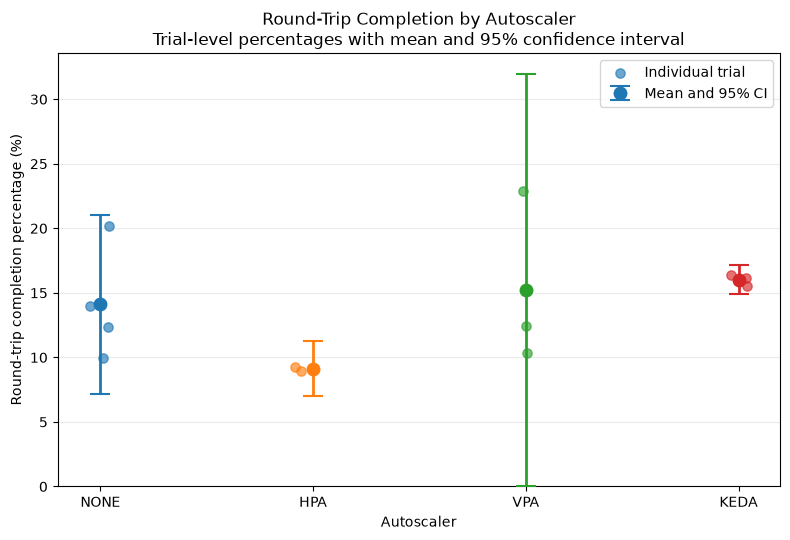

In [252]:
fig, ax = plot_roundtrip_completion_by_autoscaler(
    merged_trial_summary_df,
    autoscaler_order=["none", "hpa", "vpa", "keda"],
)

plt.show()

In [253]:
fig.savefig(
    "../figures/roundtrip_completion_by_autoscaler.png",
    dpi=300,
    bbox_inches="tight",
)

## Get benchmark starting and ending time

In [254]:
earliest_start_time, latest_end_time = get_run_start_and_end_times(files, s3_bucket, RUN)
print(f"Earliest start time: {earliest_start_time}")
print(f"Latest end time: {latest_end_time}")

Earliest start time: 2026-08-02 16:10:35.395385+00:00
Latest end time: 2026-08-03 00:50:06.124000+00:00


## Calculate synchronous $\theta$

In [258]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()
display(raw_df)
raw_df = append_time_slice(raw_df, earliest_start_time, latest_end_time, time_slice_seconds=TIME_SLICE_SECONDS)
theta_results = calculate_theta_metrics(raw_df)
weighted_theta_results = add_weighted_theta(
    theta_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_theta_results




,run_id,trial_id,role,autoscaler,user_id,request_type,name,response_time,response_length,response,status_code,reason,exception,start_time,url,method_and_name,success,failure
0,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,POST,/api/portfolios/bulk,37.952766,140,<Response [201]>,201,Created,None,2026-08-02 16:10:50.149567,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
1,exp-2026-08-02-c,trial0001,back-office,vpa,57a15a67-4cf1-40ab-93a4-501a120369da,GET,/api/portfolios/{id},29.993266,133,<Response [200]>,200,OK,None,2026-08-02 16:10:55.388726,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
2,exp-2026-08-02-c,trial0001,back-office,vpa,c66465d0-d110-477c-8b57-5774d4b43bb7,GET,/api/portfolios/{id},19.078246,133,<Response [200]>,200,OK,None,2026-08-02 16:10:56.047427,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
3,exp-2026-08-02-c,trial0001,back-office,vpa,6f30fe02-1471-407b-8d1b-c595820215fd,POST,/api/portfolios/bulk,25.788154,140,<Response [201]>,201,Created,None,2026-08-02 16:10:56.638008,http://kasb-20260802155403297400000014-b2f3dc0...,POST /api/portfolios/bulk,1,0
4,exp-2026-08-02-c,trial0001,back-office,vpa,48c703ae-ad00-4893-9724-d40ba747dda9,GET,/api/portfolios/{id},22.076400,133,<Response [200]>,200,OK,None,2026-08-02 16:10:58.535957,http://kasb-20260802155403297400000014-b2f3dc0...,GET /api/portfolios/{id},1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234114,exp-2026-08-02-c,trial0012,trader,hpa,2569a186-c143-47ff-b52c-90aefa84a63b,POST,/api/trade-orders/batch/submit,29.189712,1044,<Response [200]>,200,OK,None,2026-08-03 00:49:57.041504,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234115,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,13.796214,622,<Response [200]>,200,OK,None,2026-08-03 00:50:04.550745,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0
234116,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,POST,/api/trade-orders/batch/submit,34.278593,1045,<Response [200]>,200,OK,None,2026-08-03 00:50:04.570462,http://kasb-20260803002024141500000014-977014f...,POST /api/trade-orders/batch/submit,1,0
234117,exp-2026-08-02-c,trial0012,trader,hpa,8a1c4ee5-a54f-424e-99c4-4b80024a60ba,GET,/api/trades?orderId,24.098116,624,<Response [200]>,200,OK,None,2026-08-03 00:50:05.332916,http://kasb-20260803002024141500000014-977014f...,GET /api/trades?orderId,1,0


,autoscaler,theta_u_rt_mean,theta_u_rt_std,theta_u_rt_count,theta_o_rt_mean,theta_o_rt_std,theta_o_rt_count,theta_u_fr_mean,theta_u_fr_std,theta_u_fr_count,theta_o_fr_mean,theta_o_fr_std,theta_o_fr_count,theta_u_rt_sem,theta_o_rt_sem,theta_u_fr_sem,theta_o_fr_sem,theta_rt_mean,theta_fr_mean,theta_mean
0,hpa,1056.209985,1288.390513,2,0.0,0.0,2,56.951872,80.542109,2,46.540590,65.818334,2,911.029668,0.0,56.951872,46.540590,528.104993,51.746231,289.925612
1,keda,273.218568,298.873046,3,0.0,0.0,3,31.901705,55.255373,3,56.911442,49.287564,3,172.554434,0.0,31.901705,28.456188,136.609284,44.406573,90.507929
2,none,2943.726351,1845.095783,4,0.0,0.0,4,917.629168,895.472084,4,21.503007,43.006015,4,922.547891,0.0,447.736042,21.503007,1471.863175,469.566088,970.714632
3,vpa,3328.250715,3153.768914,3,0.0,0.0,3,1242.674950,1160.153714,3,0.000000,0.000000,3,1820.829331,0.0,669.815059,0.000000,1664.125357,621.337475,1142.731416


## Calculate synchronous $\tau$

In [259]:
TIME_SLICE_SECONDS = 30
raw_df = df.copy()

raw_df = append_time_slice(raw_df, earliest_start_time, latest_end_time, time_slice_seconds=TIME_SLICE_SECONDS)
tau_results = calculate_tau_metrics(raw_df)

weighted_tau_results = add_weighted_tau(
    tau_results.autoscalers,
    gamma=0.50,
    omega=0.50,
)
weighted_tau_results



,autoscaler,tau_u_rt_mean,tau_u_rt_std,tau_u_rt_count,tau_o_rt_mean,tau_o_rt_std,tau_o_rt_count,tau_u_fr_mean,tau_u_fr_std,tau_u_fr_count,tau_o_fr_mean,tau_o_fr_std,tau_o_fr_count,tau_u_rt_sem,tau_o_rt_sem,tau_u_fr_sem,tau_o_fr_sem,tau_rt_mean,tau_fr_mean,tau_mean
0,hpa,100.0,0.0,2,0.0,0.0,2,50.000000,70.710678,2,50.000000,70.710678,2,0.0,0.0,50.000000,50.000000,50.0,50.0,50.0
1,keda,100.0,0.0,3,0.0,0.0,3,33.333333,57.735027,3,66.666667,57.735027,3,0.0,0.0,33.333333,33.333333,50.0,50.0,50.0
2,none,100.0,0.0,4,0.0,0.0,4,75.000000,50.000000,4,25.000000,50.000000,4,0.0,0.0,25.000000,25.000000,50.0,50.0,50.0
3,vpa,100.0,0.0,3,0.0,0.0,3,100.000000,0.000000,3,0.000000,0.000000,3,0.0,0.0,0.000000,0.000000,50.0,50.0,50.0


## Calculate asynchronous $\theta$ and $\tau$

Metrics: kafka_consumer_group_lag_sum_ratio, kube_deployment_status_replicas-deployment, kafka_consumer_processing_seconds_total-service_name-topic, kafka_consumer_idle_seconds_total-service_name-topic

In [379]:
lag_df, agg_df = get_asynchronous_metrics(files, run_id, s3_bucket, earliest_start_time, latest_end_time,
    l_max=5, l_target=5, n_min=0, u_target=0.50, gamma=0.50, omega=0.50, time_slice_seconds=15)

In [380]:
lag_df

,timestamp,topic,autoscaler,trial_id,lag,deployment,replicas,service_name,time_slice,idle,...,theta_a_u,tau_a_u,overprovisioned_ts,lag_at_or_below_target,replicas_above_minimum,overprovisioned_ratio,theta_a_o,underutilization,lag_under_target,tau_a_o
0,2026-08-02 16:12:50.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:35.395385+00:00, 2026-08-02 ...",0.674340,...,0.0,0,0,1,1,0.987190,0.987190,1,1,0
1,2026-08-02 16:13:05.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:50.395385+00:00, 2026-08-02 ...",0.829206,...,0.0,0,0,1,1,0.989083,0.989083,1,1,0
2,2026-08-02 16:13:20.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:05.395385+00:00, 2026-08-02 ...",0.921064,...,0.0,0,0,1,1,0.978951,0.978951,1,1,0
3,2026-08-02 16:13:35.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:20.395385+00:00, 2026-08-02 ...",0.985895,...,0.0,0,0,1,1,0.979067,0.979067,1,1,0
4,2026-08-02 16:13:50.394999+00:00,orders,vpa,trial0001,0.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:35.395385+00:00, 2026-08-02 ...",0.987332,...,0.0,0,1,1,1,0.971173,0.971173,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2536,2026-08-03 00:48:56.858000+00:00,fills,hpa,trial0012,2.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:48:50.395385+00:00, 2026-08-03 ...",1.007679,...,0.0,0,0,1,1,0.907623,0.907623,1,1,0
2537,2026-08-03 00:49:11.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:05.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2538,2026-08-03 00:49:26.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:20.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2539,2026-08-03 00:49:41.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:35.395385+00:00, 2026-08-03 ...",0.974495,...,0.0,0,0,1,1,0.892283,0.892283,1,1,0


In [381]:
agg_df

,autoscaler,lag_mean,theta_a_u,theta_a_o,tau_a_u,tau_a_o,theta_a,tau_a
0,hpa,1.112150,0.093458,87.534949,0.467290,44.626168,43.814204,22.546729
1,keda,2.476562,9.875000,78.197584,14.687500,27.812500,44.036292,21.250000
2,none,0.936980,0.047562,84.350464,0.237812,42.687277,42.199013,21.462545
3,vpa,0.935127,0.253165,85.147474,1.265823,45.411392,42.700319,23.338608


# Ignore below this line

### Calculate utilization $U_t$

In [ ]:
async_utilization, time_slice_seconds = calculate_async_utilization_by_autoscaler(files, RUN, s3_bucket, earliest_start_time, latest_end_time)



In [ ]:
L_MAX = 5  # Maximum tolerable lag
L_TARGET = 5 # Target tolerable lag
N_MIN = 0  # Minimum replicas
U_TARGET = 0.5  # Target utilization
GAMMA = 0.50
OMEGA = 0.50

metric = "kafka_consumer_group_lag_sum_ratio"
column_label = "lag"

lag_df_original = get_merged_range_metric_df(files, RUN, s3_bucket, metric, column_label)


In [382]:
n_df_original = get_merged_range_metric_df(files, RUN, s3_bucket, "kube_deployment_status_replicas-deployment", "replicas")


In [358]:
print(f"minimum timestamp = {earliest_start_time}")
print(f"maximum timestamp = {latest_end_time}")

lag_df = lag_df_original.copy()
n_df = n_df_original.copy()


# Filter columns
lag_df = lag_df[['timestamp', 'topic', 'autoscaler','trial_id', 'lag']]
print(f"Original length of lag_df: {len(lag_df)}")
# Add column "deployment" to lag_df
lag_df["deployment"] = np.where(lag_df.topic == "orders", "globeco-fix-engine", "globeco-confirmation-service")
n_df = n_df[['timestamp', 'autoscaler','trial_id', 'replicas', 'deployment']]
# Merge lag and n dataframes
lag_df = lag_df.merge(n_df, on=["timestamp", "autoscaler", "trial_id", "deployment"], suffixes=["_lag", "_n"])
# Print length of lag_df after the merge with n_df
print(f"Length of lag_df after merging with n_df: {len(lag_df)}")
# Convert timestamp to UTC 
lag_df["timestamp"] = pd.to_datetime(lag_df["timestamp"], unit="s", utc=True).astype('datetime64[us, UTC]')
# Mege lag_df and utilization on timestamp autoscaler, trial_id, and topic
lag_df = lag_df.merge(async_utilization, on=["timestamp", "autoscaler", "trial_id", "topic"], suffixes=["_lag", "_utilization"])
# Print the length of lag_df after merging with utilization: {len(lag_df)}")
print(f"Length of lag_df after merging with utilization: {len(lag_df)}")

# Calculate interval_range from the ealiest to latest start time
time_slice_index = pd.interval_range(
    start=earliest_start_time, 
    end=latest_end_time,
    freq=pd.Timedelta(seconds=time_slice_seconds),
    name="time_slice",
)


# Assign each row to a time slice based on start_time
lag_df["time_slice"] = pd.cut(
    lag_df.timestamp,
    bins=time_slice_index,
    include_lowest=True, 
    labels=time_slice_index[:],
)

# Add "theta_a_u" column
lag_df["theta_a_u"] = (lag_df.lag - L_MAX).clip(lower=0)/L_MAX

# Add "tau_a_u" time-slice column
lag_df["tau_a_u"] = np.where(lag_df.lag > L_MAX, 1, 0)

# Add overprovisioned time-slice column
lag_df["overprovisioned_ts"] = np.where(lag_df.lag == 0, 1, 0)

# Add "lag_at_or_below_target" column (ones)
lag_df["lag_at_or_below_target"] = np.where(lag_df.lag <= L_TARGET, 1, 0)

# Add "replicas_above_minimum" column (ones)
lag_df["replicas_above_minimum"] = np.where(lag_df.replicas > N_MIN, 1, 0)

# Add "overprovisioned_ratio" column
lag_df["overprovisioned_ratio"] = np.maximum(U_TARGET - lag_df.u_t, 0)/U_TARGET

# Add "theta_a_o" column
lag_df["theta_a_o"] = lag_df["overprovisioned_ratio"] * lag_df["lag_at_or_below_target"] * lag_df["replicas_above_minimum"]

# Add "underutilization" column (ones)
lag_df["underutilization"] = np.where(lag_df.u_t < U_TARGET, 1, 0)

# Add "lag_under_target" column (ones
lag_df["lag_under_target"] = np.where(lag_df.lag <= L_TARGET, 1, 0)

# Add "tau_a_o" column
lag_df["tau_a_o"] = lag_df["overprovisioned_ts"] * lag_df["lag_at_or_below_target"] * lag_df["replicas_above_minimum"]




lag_df




minimum timestamp = 2026-08-02 16:10:35.395385+00:00
maximum timestamp = 2026-08-03 00:50:06.124000+00:00
Original length of lag_df: 2614
Length of lag_df after merging with n_df: 2614
Length of lag_df after merging with utilization: 2541


,timestamp,topic,autoscaler,trial_id,lag,deployment,replicas,service_name,time_slice,idle,...,theta_a_u,tau_a_u,overprovisioned_ts,lag_at_or_below_target,replicas_above_minimum,overprovisioned_ratio,theta_a_o,underutilization,lag_under_target,tau_a_o
0,2026-08-02 16:12:50.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:35.395385+00:00, 2026-08-02 ...",0.674340,...,0.0,0,0,1,1,0.987190,0.987190,1,1,0
1,2026-08-02 16:13:05.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:12:50.395385+00:00, 2026-08-02 ...",0.829206,...,0.0,0,0,1,1,0.989083,0.989083,1,1,0
2,2026-08-02 16:13:20.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:05.395385+00:00, 2026-08-02 ...",0.921064,...,0.0,0,0,1,1,0.978951,0.978951,1,1,0
3,2026-08-02 16:13:35.394999+00:00,orders,vpa,trial0001,1.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:20.395385+00:00, 2026-08-02 ...",0.985895,...,0.0,0,0,1,1,0.979067,0.979067,1,1,0
4,2026-08-02 16:13:50.394999+00:00,orders,vpa,trial0001,0.0,globeco-fix-engine,1.0,globeco-fix-engine,"(2026-08-02 16:13:35.395385+00:00, 2026-08-02 ...",0.987332,...,0.0,0,1,1,1,0.971173,0.971173,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2536,2026-08-03 00:48:56.858000+00:00,fills,hpa,trial0012,2.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:48:50.395385+00:00, 2026-08-03 ...",1.007679,...,0.0,0,0,1,1,0.907623,0.907623,1,1,0
2537,2026-08-03 00:49:11.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:05.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2538,2026-08-03 00:49:26.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:20.395385+00:00, 2026-08-03 ...",1.008357,...,0.0,0,0,1,1,0.858011,0.858011,1,1,0
2539,2026-08-03 00:49:41.858000+00:00,fills,hpa,trial0012,1.0,globeco-confirmation-service,1.0,globeco-confirmation-service,"(2026-08-03 00:49:35.395385+00:00, 2026-08-03 ...",0.974495,...,0.0,0,0,1,1,0.892283,0.892283,1,1,0


In [359]:
# Verify that there is a one-to-one relationship between timestamps and time slices

print(len(lag_df.timestamp.unique()))
print(len(lag_df.time_slice.unique()))

assert len(lag_df.timestamp.unique()) == len(lag_df.time_slice.unique())


637
637


In [ ]:
GAMMA = 0.50
OMEGA = 0.50
agg_df = (
        lag_df
        .groupby(["autoscaler"], observed=True, dropna=False)
        .agg(
            lag_mean=("lag","mean"),
            theta_a_u= ("theta_a_u", lambda values: 100.0 * values.mean()),
            theta_a_o= ("theta_a_o", lambda values: 100.0 * values.mean()),
            tau_a_u = ("tau_a_u", lambda values: 100.0 * values.mean()),
            tau_a_o = ("tau_a_o", lambda values: 100.0 * values.mean()),
        )
        .reset_index()
    )

agg_df

agg_df["theta_a"] =  GAMMA * agg_df.theta_a_u + (1 - GAMMA) * agg_df.theta_a_o
agg_df["tau_a"] =  OMEGA * agg_df.tau_a_u + (1 - OMEGA) * agg_df.tau_a_o
agg_df


,autoscaler,lag_mean,theta_a_u,theta_a_o,tau_a_u,tau_a_o,theta_a,tau_a
0,hpa,1.112150,0.093458,87.534949,0.467290,44.626168,83.162875,42.418224
1,keda,2.476562,9.875000,78.197584,14.687500,27.812500,74.781455,27.156250
2,none,0.936980,0.047562,84.350464,0.237812,42.687277,80.135319,40.564804
3,vpa,0.935127,0.253165,85.147474,1.265823,45.411392,80.902759,43.204114


<Axes: >

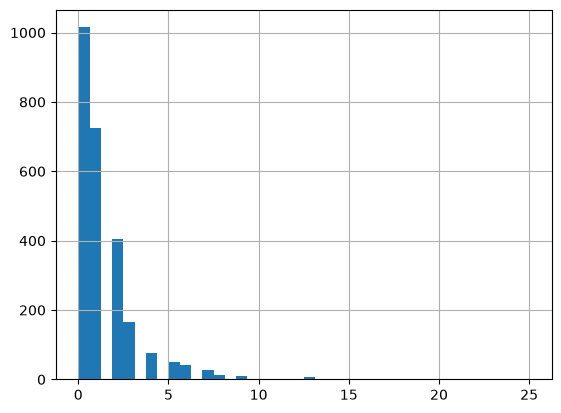

In [323]:
lag_df.lag.hist(bins=40)

In [209]:
lag_df.lag.describe()

count    2614.000000
mean        1.332823
std         1.977915
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max        25.000000
Name: lag, dtype: float64

In [102]:
# get contents of {s3_bucket}/trial0001/metrics/kafka_consumer_idle_seconds_total-service_name-topic from s3
s3 = boto3.client('s3')
run_id = RUN
trial_id = "trial0001"
key = f"{run_id}/{trial_id}/metrics/kafka_consumer_idle_seconds_total-service_name-topic"
obj = s3.get_object(Bucket=s3_bucket, Key=key)
metrics = json.loads(obj['Body'].read())
metrics = metrics["data"]["result"]
metrics

[{'metric': {'service_name': 'globeco-confirmation-service', 'topic': 'fills'},
  'values': [[1785687170.395, '0.9057194978749533'],
   [1785687185.395, '0.9769030177666667'],
   [1785687200.395, '1.0110339440333334'],
   [1785687215.395, '1.0110339440333334'],
   [1785687230.395, '1.0108820449'],
   [1785687245.395, '1.0108820449'],
   [1785687260.395, '0.9766131089333333'],
   [1785687275.395, '0.9766131089333333'],
   [1785687290.395, '1.0098367659333334'],
   [1785687305.395, '1.0098367659333334'],
   [1785687320.395, '1.0099316906333333'],
   [1785687335.395, '1.0099316906333333'],
   [1785687350.395, '1.0092396126666665'],
   [1785687365.395, '1.0092396126666665'],
   [1785687380.395, '0.9754416626666667'],
   [1785687395.395, '0.9754416626666667'],
   [1785687410.395, '1.0094875440666666'],
   [1785687425.395, '1.0094875440666666'],
   [1785687440.395, '1.0090494887666668'],
   [1785687455.395, '1.0090494887666668'],
   [1785687470.395, '1.0099049639'],
   [1785687485.395, '1.00

In [ ]:
df = MetricRangeDataFrame(metrics)
df

,service_name,topic,value
timestamp,,,
2026-08-02 16:12:50.394999981,globeco-confirmation-service,fills,0.905719
2026-08-02 16:13:05.394999981,globeco-confirmation-service,fills,0.976903
2026-08-02 16:13:20.394999981,globeco-confirmation-service,fills,1.011034
2026-08-02 16:13:35.394999981,globeco-confirmation-service,fills,1.011034
2026-08-02 16:13:50.394999981,globeco-confirmation-service,fills,1.010882
...,...,...,...
2026-08-02 16:24:35.394999981,globeco-fix-engine,orders,0.996755
2026-08-02 16:24:50.394999981,globeco-fix-engine,orders,1.006404
2026-08-02 16:25:05.394999981,globeco-fix-engine,orders,1.006404
